In [1]:
"""
Shared Data Pipeline
====================
Shared data loading and preprocessing functions used across all models.
Put your common data cleaning, feature engineering, and splitting logic here.

Usage from any model:
    import sys
    sys.path.insert(0, str(Path(__file__).resolve().parents[1]))
    from pipelines.data_pipeline import load_raw_data, preprocess, split_data
"""
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#import sys
#sys.path.insert(0, str(Path(__file__).resolve().parents[1]))

from pathlib import Path
import sys

project_root = Path.cwd().parent  # or adjust levels
sys.path.insert(0, str(project_root))

In [3]:


# Project paths
PROJECT_ROOT = project_root #Path(__file__).resolve().parents[1]
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

In [4]:
#print(project_root)
#print(PROJECT_ROOT)
print(RAW_DATA_DIR)

C:\Git_Repo\final-capstone-e2ws-ai-topia-consulting\data\raw


In [117]:
filepath = RAW_DATA_DIR / "city_traffic_accidents.csv"
df = pd.read_csv(filepath)

#keep a copy of original data before making changes
df_orig = df.copy()


In [118]:
# cleaning - change all text to lower case

df = df.apply(lambda x: x.str.lower() if x.dtype == 'object' else x)


In [119]:
    # Parse datetime columns
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['End_Time'] = pd.to_datetime(df['End_Time'], errors='coerce')
df['Weather_Timestamp'] = pd.to_datetime(df['Weather_Timestamp'], errors='coerce')

In [120]:
# Display basic info
print(f"Dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nColumn names:")
print(df.columns.tolist())

Dataset shape: 500,000 rows, 46 columns

Column names:
['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


In [121]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,a-1784167,source2,2,2019-10-29 13:16:54,2019-10-29 15:21:34,35.834797,-78.638512,NaN,NaN,0.000,...,False,False,False,False,False,False,day,day,day,day
1,a-862811,source2,2,2021-10-13 06:30:00,2021-10-13 06:59:15,36.088970,-96.011734,NaN,NaN,0.000,...,False,False,False,False,False,False,night,night,night,day
2,a-4054572,source1,2,2022-08-14 14:42:58,2022-08-14 16:27:58,33.537049,-86.794445,33.535373,-86.796156,0.152,...,False,False,False,False,False,False,day,day,day,day
3,a-6147589,source1,2,2021-06-25 19:13:44,2021-06-25 20:42:30,34.071722,-117.612886,34.078917,-117.625339,0.869,...,False,False,False,False,False,False,day,day,day,day
4,a-5025169,source1,2,2022-03-18 12:50:30,2022-03-18 13:13:00,40.324235,-76.790464,40.322625,-76.788114,0.166,...,False,False,False,False,False,False,day,day,day,day


In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   ID                     500000 non-null  object        
 1   Source                 500000 non-null  object        
 2   Severity               500000 non-null  int64         
 3   Start_Time             452263 non-null  datetime64[ns]
 4   End_Time               452263 non-null  datetime64[ns]
 5   Start_Lat              500000 non-null  float64       
 6   Start_Lng              500000 non-null  float64       
 7   End_Lat                280022 non-null  float64       
 8   End_Lng                280022 non-null  float64       
 9   Distance(mi)           500000 non-null  float64       
 10  Description            500000 non-null  object        
 11  Street                 499346 non-null  object        
 12  City                   499972 non-null  obje

In [123]:
#df.describe()

### Model 1: Traffic Accident Severity — Traditional ML

- Multi-class classification: predict accident severity (1-4 scale)
- This dataset has significant class imbalance — your approach to handling it will be a key evaluation criterion. **Weighted F1 is the real evaluation metric**, not accuracy.
- Use classical ML algorithms (XGBoost, Random Forest, Gradient Boosting, etc.)
- Must be interpretable — city planners need to understand WHY an intersection is flagged as high-risk
- **Minimum Benchmark:** Accuracy > 70%, weighted F1 > 0.55
- **Stretch Goal:** Accuracy > 80%, weighted F1 > 0.70
- **Required:** SHAP or feature importance analysis — which factors most predict severe accidents?

In [124]:
# This is a classification problem, we need to convert Severity to integer
df['Target'] = df['Severity'].astype(int) 

In [125]:
# Define your target variable
TARGET = 'Target'  # <-- UPDATE THIS!

# Basic statistics of target
print(f"Target Variable: {TARGET}")
print(f"\nBasic Statistics:")
print(df[TARGET].describe())

Target Variable: Target

Basic Statistics:
count    500000.000000
mean          2.212386
std           0.487531
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max           4.000000
Name: Target, dtype: float64


In [126]:
df['Target'].value_counts()

Target
2    398335
3     84063
4     13244
1      4358
Name: count, dtype: int64

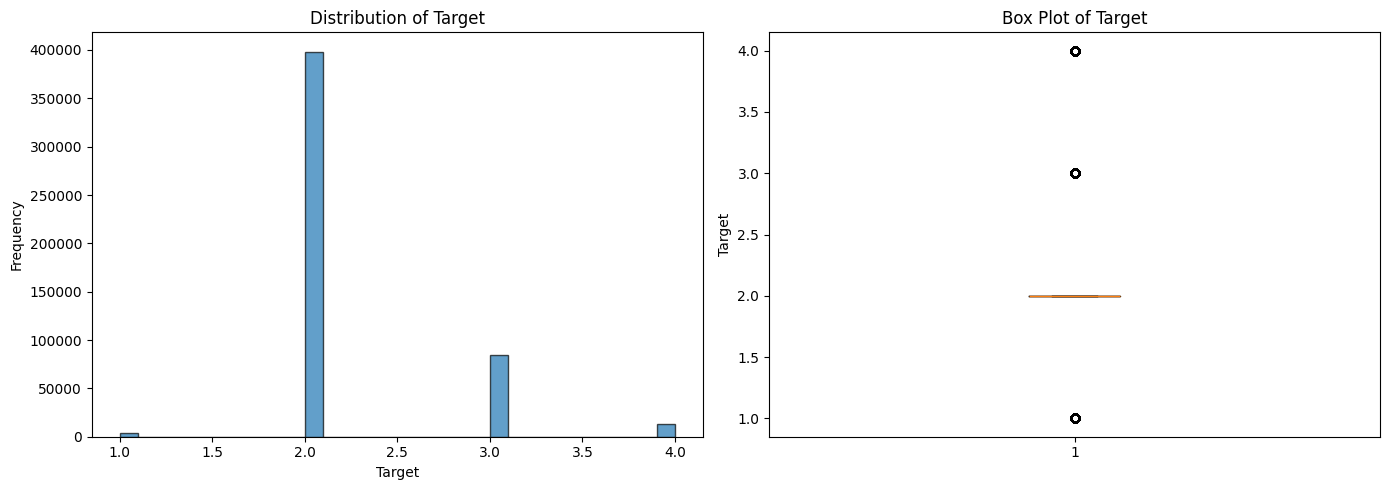


Skewness: 1.81
→ Target is highly skewed. Consider log transform in feature engineering.


In [127]:
# Distribution of target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df[TARGET].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel(TARGET)
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Distribution of {TARGET}')

# Box plot
axes[1].boxplot(df[TARGET].dropna())
axes[1].set_ylabel(TARGET)
axes[1].set_title(f'Box Plot of {TARGET}')

plt.tight_layout()
plt.show()

# Check skewness
skewness = df[TARGET].skew()
print(f"\nSkewness: {skewness:.2f}")
if abs(skewness) > 1:
    print("→ Target is highly skewed. Consider log transform in feature engineering.")
elif abs(skewness) > 0.5:
    print("→ Target is moderately skewed.")
else:
    print("→ Target is approximately symmetric.")

In [128]:
# TODO: Check for duplicate rows in your dataframe
#
# Steps:
# 1. Count how many duplicate rows exist using df.duplicated().sum()
# 2. Print the count and the percentage of duplicates
#
# Expected output format:
# "Duplicate rows: X,XXX (X.XX%)"

# YOUR CODE HERE:
duplicate_rows = df[df.duplicated()]
pct_duplicated = len(duplicate_rows)/len(df)
print(f"Duplicated rows: {len(duplicate_rows):,}, ({pct_duplicated:.2%})")

Duplicated rows: 0, (0.00%)


In [146]:
!pip install uszipcode

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 21.2 MB/s  0:00:00
  Created wheel for atomicwrites: filename=atomicwrites-1.4.1-py2.py3-none-any.whl size=7054 sha256=5570982af758ff262aa8a6495d318cbd552056eb09035cf7c76d79c6b164ca34
  Stored in directory: c:\users\wzhu2\appdata\local\pip\cache\wheels\17\5c\07\1cbbde9c113ebe939ffd48f9cf7f16e8f170f816792508d044
Successfully built atomicwrites

   -------- ------------------------------- 2/9 [pathlib-mate]
   ----------------- ---------------------- 4/9 [greenlet]
   -------------------------- ------------- 6/9 [SQLAlchemy]
   --------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [145]:
import pandas as pd
from uszipcode import SearchEngine
import airportsdata

# 1. Get Zipcode coordinates
search = SearchEngine()
zip_data = search.by_zipcode("90210") # Example zipcode
lat, lng = zip_data.lat, zip_data.lng

# 2. Load airport database
airports = airportsdata.load('IATA') # Returns a dict of airport data

# 3. Use pandas to find the closest airport
df_airports = pd.DataFrame.from_dict(airports, orient='index')

# Calculate distance (simplified Haversine or Euclidean for nearby lookups)
df_airports['dist'] = ((df_airports['lat'] - lat)**2 + (df_airports['lon'] - lng)**2)**0.5
closest_airport = df_airports.nsmallest(1, 'dist').index[0]

print(f"Closest Airport to 90210: {closest_airport}")


ModuleNotFoundError: No module named 'uszipcode'

In [129]:
# Missing values must be treated carefully, using business logic

# 1. End_Lat and End_Lng can be set to be approx. 0.5 miles away from Start_lat & Start_lng
def quick_offset(lat, lng, max_distance_miles=0.5):
    if pd.isna(lat) or pd.isna(lng):
        return np.nan, np.nan

    distance = np.random.uniform(0, max_distance_miles)
    angle = np.random.uniform(0, 2 * np.pi)

    # Approximate conversions
    dlat = (distance / 69.0) * np.cos(angle)
    dlng = (distance / (69.0 * np.cos(np.radians(lat)))) * np.sin(angle)

    return lat + dlat, lng + dlng

    

In [130]:
mask = df['End_Lat'].isna() | df['End_Lng'].isna()

new_coords = df.loc[mask].apply(
    lambda row: quick_offset(
        row['Start_Lat'], row['Start_Lng'], max_distance_miles=0.5
    ),
    axis=1
)

# Convert list of tuples → DataFrame
new_coords = pd.DataFrame(new_coords.tolist(), index=df.loc[mask].index, columns=['End_Lat', 'End_Lng'])

# Assign back
df.loc[mask, ['End_Lat', 'End_Lng']] = new_coords

In [131]:
#df.loc[mask, ['Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng']].head()

In [132]:
df[['Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng']].isna().sum()

Start_Lat    0
Start_Lng    0
End_Lat      0
End_Lng      0
dtype: int64

**CHECKPOINT** - 03.21.2026

In [133]:
median_time_elapsed = (df['End_Time'] - df['Start_Time']).median()

In [134]:
df.fillna({'Start_Time': df['Start_Time'].median()}, inplace=True)

In [135]:
df.fillna({'End_Time': df['Start_Time']+median_time_elapsed}, inplace=True)

In [136]:
df.fillna({'Precipitation(in)': df['Precipitation(in)'].median()}, inplace=True)

In [137]:
df.fillna({'Wind_Chill(F)': df['Wind_Chill(F)'].median()}, inplace=True)

In [138]:
df.fillna({'Wind_Speed(mph)': df['Wind_Speed(mph)'].median(),
           'Visibility(mi)': df['Visibility(mi)'].median(),
           'Humidity(%)': df['Humidity(%)'].median()}, inplace=True)

In [139]:
df.fillna({'Temperature(F)': df['Temperature(F)'].median(),
           'Pressure(in)': df['Pressure(in)'].median(),
           'Weather_Timestamp': df['Weather_Timestamp'].median()}, inplace=True)

In [140]:
# for categorical columns, fillna with 'Missing' to preserve the fact that data is missing

df.fillna({'Wind_Direction': 'missing',
           'Weather_Condition': 'missing',
           'Civil_Twilight': 'missing',
           'Nautical_Twilight': 'missing',
           'Astronomical_Twilight': 'missing',
           'Sunrise_Sunset': 'missing',
           
          }, inplace=True)

In [144]:

df[['City', 'Airport_Code']].isna().sum()


City              28
Airport_Code    1514
dtype: int64

In [115]:
# TODO: Create a summary of missing values
#
# Steps:
# 1. Calculate missing count for each column: df.isnull().sum()
# 2. Calculate missing percentage: (df.isnull().sum() / len(df)) * 100
# 3. Create a DataFrame with 'Missing Count' and 'Missing %' columns
# 4. Sort by 'Missing %' descending
# 5. Display only columns that have missing values
#
# Hint: You can create a DataFrame with pd.DataFrame({'col1': series1, 'col2': series2})

# YOUR CODE HERE:
missing_cnt = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_cnt,
    'Missing %': missing_pct
})

# 4. Filter to display only columns that have missing values (Count > 0)
#    and sort by 'Missing %' in descending order
missing_df = missing_df[missing_df['Missing Count'] > 0]
missing_df = missing_df.sort_values(by='Missing %', ascending=False)

# 5. Display the result
#print(missing_df)

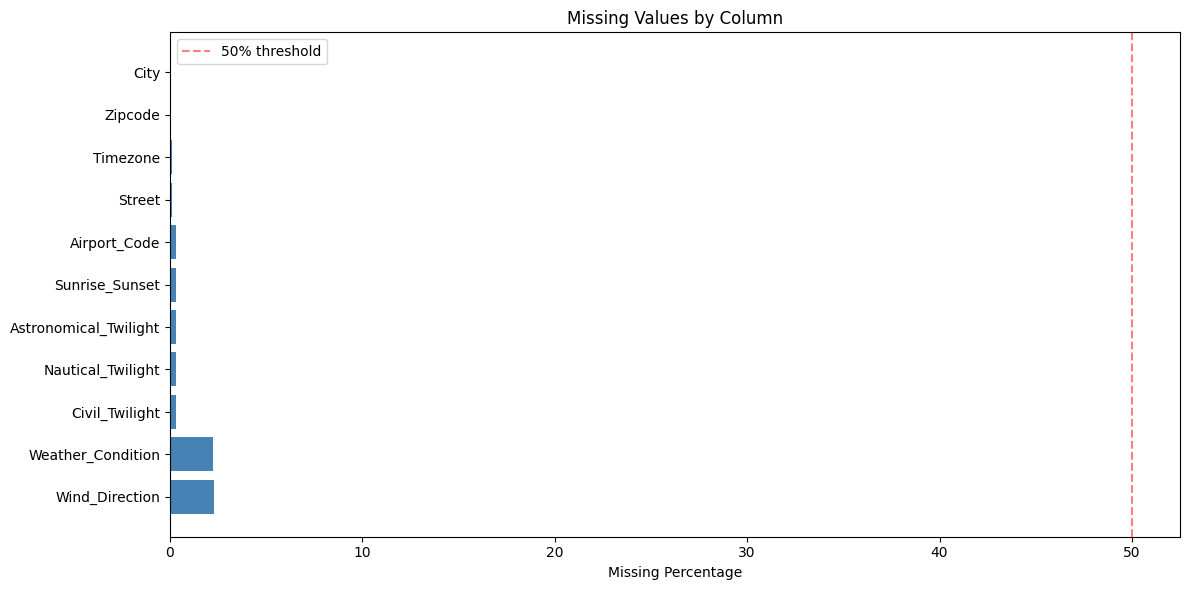

In [116]:
# Visualize missing values (if any)
if df.isnull().sum().sum() > 0:
    plt.figure(figsize=(12, 6))
    missing_cols = missing_df[missing_df['Missing Count'] > 0]
    colors = ['red' if pct > 50 else 'orange' if pct > 20 else 'steelblue' 
              for pct in missing_cols['Missing %']]
    plt.barh(missing_cols.index, missing_cols['Missing %'], color=colors)
    plt.xlabel('Missing Percentage')
    plt.title('Missing Values by Column')
    plt.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Recommendation
    high_missing = missing_cols[missing_cols['Missing %'] > 50]
    if len(high_missing) > 0:
        print(f"\n⚠️ Columns with >50% missing (consider dropping): {high_missing.index.tolist()}")
else:
    print("✓ No missing values in the dataset!")

In [ ]:
"""
Smart City Data Preprocessing Hints
=====================================
These are HINTS, not complete solutions. Use them as a starting point
for your data pipeline. You'll need to adapt and expand these for your
specific models.

Datasets:
- city_traffic_accidents.csv (~500K accident records)
- pothole_images/ (~4,400 road surface images)
- urbanpulse_311_complaints.csv (~500K complaint records)
"""

# =============================================================================
# *** CLASS IMBALANCE WARNING ***
# =============================================================================
# EVERY dataset in this project has class imbalance. If you ignore it,
# your model will learn to predict the majority class and look "accurate"
# while being clinically useless.
#
# Techniques you MUST consider for every model:
#   1. class_weight='balanced' in sklearn models (easiest first step)
#   2. SMOTE (Synthetic Minority Oversampling) from imblearn
#   3. Stratified train/test splits (use stratify= in train_test_split)
#   4. Weighted loss functions in TensorFlow/Keras
#   5. Evaluation with weighted F1, precision, recall — NOT just accuracy
#
# A model that predicts the majority class for everything is WORTHLESS
# even if it gets 80%+ accuracy. Always check per-class metrics.
# =============================================================================

import pandas as pd
import numpy as np
from pathlib import Path


# =============================================================================
# HINT 1: Loading the Accident Data
# =============================================================================

def load_accidents(filepath: str) -> pd.DataFrame:
    """
    Load the city traffic accidents dataset.

    Key gotchas:
    - Severity is 1-4 scale measuring TRAFFIC IMPACT, not injury severity
    - Severity 2 dominates (~80% of records) — MAJOR class imbalance
      A naive model that predicts Severity 2 for everything gets ~80% accuracy
      but is completely useless. You MUST use class weights or SMOTE.
      Weighted F1 is the real metric, not accuracy.
    - Datetime columns need parsing
    - Weather columns have significant missing values
    - Some lat/lng values are null (End_Lat, End_Lng especially)
    """
    df = pd.read_csv(filepath)

    # Parse datetime columns
    df['Start_Time'] = pd.to_datetime(df['Start_Time'])
    df['End_Time'] = pd.to_datetime(df['End_Time'])

    return df


# =============================================================================
# HINT 2: Temporal Feature Engineering
# =============================================================================

def create_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Time patterns are among the strongest predictors of accident severity.

    Features to extract:
    - Hour of day (rush hour vs. off-peak)
    - Day of week (weekday vs. weekend)
    - Month (seasonal patterns — winter ice, summer heat)
    - Duration of traffic impact
    - Is it dark? (Sunrise_Sunset column helps, but you can derive from time too)
    """
    df['hour'] = df['Start_Time'].dt.hour
    df['day_of_week'] = df['Start_Time'].dt.dayofweek
    df['month'] = df['Start_Time'].dt.month
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    # Rush hour flags
    df['is_morning_rush'] = df['hour'].between(7, 9).astype(int)
    df['is_evening_rush'] = df['hour'].between(16, 19).astype(int)
    df['is_rush_hour'] = (df['is_morning_rush'] | df['is_evening_rush']).astype(int)

    # Duration of traffic impact (in minutes)
    if 'End_Time' in df.columns:
        df['duration_min'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60
        # Cap extreme values
        df['duration_min'] = df['duration_min'].clip(0, 1440)  # Max 24 hours

    return df


# =============================================================================
# HINT 3: Weather Feature Processing
# =============================================================================

def process_weather_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Weather is a major factor in accident severity.

    Missing values in weather columns are NOT random — they often mean:
    - Weather station was offline
    - Data wasn't available at the time of the accident
    - The weather API didn't return data for that location

    Strategy: Create a "weather_data_available" flag, then impute or drop.

    Key weather features:
    - Temperature(F): Freezing conditions are dangerous
    - Visibility(mi): Low visibility = more severe accidents
    - Precipitation(in): Rain/snow increases severity
    - Weather_Condition: Categorical (Clear, Rain, Snow, Fog, etc.)
    """
    weather_cols = ['Temperature(F)', 'Humidity(%)', 'Pressure(in)',
                    'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']

    # Flag for whether weather data is available
    df['weather_data_available'] = df[weather_cols].notna().all(axis=1).astype(int)

    # Freezing conditions
    if 'Temperature(F)' in df.columns:
        df['is_freezing'] = (df['Temperature(F)'] <= 32).astype(int)

    # Low visibility
    if 'Visibility(mi)' in df.columns:
        df['low_visibility'] = (df['Visibility(mi)'] < 2).astype(int)

    # Group weather conditions
    if 'Weather_Condition' in df.columns:
        df['weather_group'] = df['Weather_Condition'].apply(categorize_weather)

    return df


def categorize_weather(condition) -> str:
    """Group detailed weather conditions into broader categories."""
    if pd.isna(condition):
        return 'unknown'

    condition = str(condition).lower()

    if any(w in condition for w in ['clear', 'fair']):
        return 'clear'
    elif any(w in condition for w in ['cloud', 'overcast']):
        return 'cloudy'
    elif any(w in condition for w in ['rain', 'drizzle', 'shower']):
        return 'rain'
    elif any(w in condition for w in ['snow', 'sleet', 'ice', 'wintry']):
        return 'snow_ice'
    elif any(w in condition for w in ['fog', 'mist', 'haze', 'smoke']):
        return 'low_visibility'
    elif any(w in condition for w in ['thunder', 'storm']):
        return 'storm'
    else:
        return 'other'


# =============================================================================
# HINT 4: Road Feature Processing
# =============================================================================

def process_road_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    The dataset has 13 boolean road feature columns.

    These are already binary (True/False) and very useful for ML models.
    Consider creating aggregate features:
    - total_road_features: count of road features at the accident location
    - has_traffic_control: any of traffic signal, stop, give way, etc.
    """
    road_features = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction',
                     'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
                     'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop']

    existing = [f for f in road_features if f in df.columns]

    # Total road features present
    df['n_road_features'] = df[existing].sum(axis=1)

    # Traffic control present
    control_features = ['Traffic_Signal', 'Stop', 'Give_Way', 'Traffic_Calming']
    existing_control = [f for f in control_features if f in df.columns]
    df['has_traffic_control'] = df[existing_control].any(axis=1).astype(int)

    return df


# =============================================================================
# HINT 5: Handling Severity Class Imbalance
# =============================================================================

def analyze_severity_distribution(df: pd.DataFrame):
    """
    Severity distribution is heavily imbalanced:
    - Severity 1: ~1-2% (very rare)
    - Severity 2: ~80% (dominant — this is your biggest challenge)
    - Severity 3: ~12-15%
    - Severity 4: ~5-8%

    This is a MAJOR challenge. If you just predict class 2 for everything,
    you'll get ~80% accuracy but your model is COMPLETELY USELESS.
    Weighted F1 is the real evaluation metric, not accuracy.

    Strategies:
    1. Class weights: Give higher weight to minority classes
       - sklearn: class_weight='balanced'
       - TensorFlow/Keras: class_weight parameter in model.fit()
    2. SMOTE or oversampling for minority classes
    3. Undersampling the majority class (Severity 2)
    4. Consider binary: "severe" (3-4) vs "not severe" (1-2)
    5. Focal loss — designed for class imbalance

    For evaluation: Use weighted F1, not just accuracy.
    Weighted F1 accounts for class imbalance by weighting each class by its support.
    """
    print("Severity Distribution:")
    print(df['Severity'].value_counts().sort_index())
    print(f"\nClass ratios:")
    print(df['Severity'].value_counts(normalize=True).sort_index().round(3))


# =============================================================================
# HINT 6: Pothole Image Preprocessing
# =============================================================================

def get_pothole_image_hints():
    """
    Tips for working with the pothole images:

    NOTE: Images are organized in positive/ (pothole) and negative/ (normal road)
    folders. This is a simple binary classification task.

    1. Images are VERY high resolution (2760x3680px) — RESIZE FIRST
       - Common sizes: 224x224 (ResNet), 128x128 (lighter), 299x299 (Inception)
       - If you try to load full-res images, you'll run out of memory fast

    2. Class distribution — 30/70 IMBALANCE:
       - Normal road (negative/): ~2,658 images (70%)
       - Pothole (positive/): ~1,119 images (30%)
       - This 30/70 imbalance means you need class weights or augmentation
       - A model predicting "normal" for everything gets 70% accuracy — useless

    3. Data augmentation is important:
       - Random horizontal/vertical flips (roads look the same flipped)
       - Random rotation (potholes don't have an "up")
       - Color jitter (different lighting conditions)
       - RandomResizedCrop (zoom in on pothole features)
       - DO NOT use augmentation on test set — only training

    4. Transfer learning recommended:
       - ResNet50, EfficientNet-B0, or MobileNet pre-trained on ImageNet
       - Fine-tune the last few layers on your pothole data
       - Freeze early layers (edge detection, texture features transfer well)

    5. Binary classification:
       - Label 0 = Normal road
       - Label 1 = Pothole
       - Use binary_crossentropy loss in TensorFlow/Keras

    6. Image loading with TensorFlow/Keras:
       from tensorflow.keras.preprocessing.image import ImageDataGenerator

       datagen = ImageDataGenerator(
           rescale=1./255,
           rotation_range=20,
           horizontal_flip=True,
           zoom_range=0.2,
           validation_split=0.2,
       )
       train_gen = datagen.flow_from_directory(
           'pothole_images/train',
           target_size=(224, 224),
           batch_size=32,
           class_mode='binary',
           subset='training',
       )
    """
    pass


# =============================================================================
# HINT 7: 311 Complaint Text Preprocessing
# =============================================================================

def preprocess_311_text(text: str) -> str:
    """
    311 complaint text is real citizen-submitted text — it's messy!

    Common issues:
    - Informal language, abbreviations
    - ALL CAPS (common in complaints)
    - Multiple languages (English, Spanish, Chinese)
    - Very short descriptions ("noise", "pothole")
    - Very long rants (500+ words)
    - Typos and misspellings
    - Address information mixed with complaint text

    For classification:
    1. Use complaint_type as your target label
    2. Use resolution_description as your input text
    3. Focus on the top 5 most common complaint types + an "Other" bucket
       (6 classes total). The top 5 typically cover ~50-60% of complaints.
    4. Map all remaining categories into "Other" — this is a practical
       real-world decision that city operations teams would actually make

    NLP approaches:
    1. TF-IDF + Logistic Regression/SVM (strong baseline!)
    2. Word embeddings + LSTM/GRU
    3. Pre-trained transformers (DistilBERT is fast, BERT is accurate)

    Tip: TF-IDF + Logistic Regression is a surprisingly strong baseline
    for text classification. Start there before going to deep learning.
    """
    if pd.isna(text):
        return ""

    text = str(text).lower().strip()
    # Add your preprocessing steps here
    return text


def get_top_complaint_types(df: pd.DataFrame, n: int = 5) -> list:
    """
    Focus your NLP model on the top 5 complaint types + an "Other" bucket.

    With 186 categories, many have very few examples. Focusing on the top 5
    keeps your model tractable while covering the highest-impact complaint
    types. The "Other" bucket captures the long tail.

    The top 5 311 categories typically cover about 50-60% of complaints.

    The top 5 categories in this dataset are:
    - Illegal Parking
    - HEAT/HOT WATER
    - Noise - Residential
    - Snow or Ice
    - Blocked Driveway
    """
    top_types = df['complaint_type'].value_counts().head(n).index.tolist()
    coverage = df[df['complaint_type'].isin(top_types)].shape[0] / len(df) * 100
    print(f"Top {n} complaint types cover {coverage:.1f}% of all complaints")
    return top_types


def create_complaint_categories(df: pd.DataFrame) -> pd.DataFrame:
    """
    Map complaint types to the top 5 categories + "Other" (6 classes total).

    The top 5 categories are:
    - Illegal Parking
    - HEAT/HOT WATER
    - Noise - Residential
    - Snow or Ice
    - Blocked Driveway

    Everything else maps to "Other". This gives you 6 classes total —
    a much more manageable classification problem than 186 categories.
    """
    top_5 = ['Illegal Parking', 'HEAT/HOT WATER', 'Noise - Residential',
             'Snow or Ice', 'Blocked Driveway']
    df['complaint_category'] = df['complaint_type'].apply(
        lambda x: x if x in top_5 else 'Other'
    )

    print("Complaint category distribution:")
    print(df['complaint_category'].value_counts())

    coverage = df[df['complaint_category'] != 'Other'].shape[0] / len(df) * 100
    print(f"\nTop 5 categories cover {coverage:.1f}% of all complaints")
    print(f"Total classes: {df['complaint_category'].nunique()} (top 5 + Other)")

    return df


# =============================================================================
# HINT 8: Sampling the Full Dataset
# =============================================================================

def sample_accidents_data(filepath: str, n_samples: int = 500000) -> pd.DataFrame:
    """
    The full traffic accidents dataset has 7.7M records — that's a LOT.

    For this project, we provide a sampled version (~500K records).
    But if you download the full dataset, here's how to sample:

    Important: Use STRATIFIED sampling to preserve severity distribution!
    Random sampling would give you mostly Severity 2.
    """
    df = pd.read_csv(filepath)

    # Stratified sampling preserving severity distribution
    sampled = df.groupby('Severity', group_keys=False).apply(
        lambda x: x.sample(min(len(x), n_samples // 4), random_state=42)
    )

    return sampled.reset_index(drop=True)


# =============================================================================
# HINT 9: Innovation Model Ideas
# =============================================================================

def innovation_model_hints():
    """
    Your Innovation Model (Model 5) — Your Team's Choice

    This is your chance to surprise us. Identify a problem in the data
    that we DIDN'T ask you to solve, and build a model for it.

    Ideas from these datasets:
    1. Accident Hotspot Prediction
       - Cluster accidents by location to find high-risk intersections
       - Predict which intersections will see the most accidents next month
       - Huge value for proactive safety improvements

    2. Seasonal Complaint Pattern Forecasting
       - Use 311 time series data to predict complaint volumes
       - Help the city pre-position resources (e.g., more crews before pothole season)
       - Time series or regression approach

    3. Response Time Optimization
       - Predict how long 311 complaints take to resolve
       - Identify factors that slow resolution
       - Help dispatch prioritize urgent complaints

    4. Road Deterioration Prediction
       - Combine pothole data with weather/traffic patterns
       - Predict which roads will need maintenance next
       - Shift from reactive to predictive maintenance

    5. Multi-modal Accident Analysis
       - Combine accident text descriptions with structured features
       - NLP + tabular data fusion
       - Richer understanding of accident causes

    Requirements:
    - Clear urban value proposition for why this model matters
    - Defined success metric (you choose what to measure)
    - Cost-benefit estimate (how would this save taxpayer dollars?)
    - Output must match model5_results_template.csv format

    Output columns: id, prediction, confidence, metric_name, metric_value
    """
    pass


# =============================================================================
# HINT 10: Geographic Feature Engineering
# =============================================================================

def create_geographic_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Location matters for accident severity prediction.

    Feature ideas:
    1. State-level patterns (some states have more severe accidents)
    2. Urban vs. rural (can infer from city population or zip code)
    3. Latitude as a proxy for climate (northern = more ice/snow)
    4. Distance from nearest airport (proxy for traffic volume)
    5. Cluster analysis on lat/lng to find accident hotspots

    Warning: Don't use raw lat/lng as features — they're too specific
    and lead to overfitting. Instead, bin them or use for clustering.
    """
    # State-level average severity (target encoding — be careful of leakage!)
    # Only compute on training data, then apply to test

    # Latitude bins (rough climate proxy)
    if 'Start_Lat' in df.columns:
        df['lat_bin'] = pd.cut(df['Start_Lat'], bins=10, labels=False)

    return df
